In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, f1_score
)

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


Upload & Load Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()   # ← upload bank.csv or bank-full.csv

filename = list(uploaded.keys())[0]
print(f"File loaded: {filename}")

# UCI dataset uses semicolon separator
df = pd.read_csv(filename, sep=';')
print("\nDataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Saving bank-full.csv to bank-full.csv
File loaded: bank-full.csv

Dataset shape: (45211, 17)

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


Introduction & Problem Statement

In [ ]:
print("""
================================================================
  PERSONAL LOAN ACCEPTANCE PREDICTION
================================================================

PROBLEM STATEMENT:
  A bank runs telemarketing campaigns to offer personal loans
  to existing customers. Not every customer accepts the offer.
  Calling every customer is expensive and inefficient.

OBJECTIVE:
  Build a classification model to PREDICT which customers are
  likely to ACCEPT a personal loan offer — so the bank can
  focus its marketing efforts on the right people.

TARGET VARIABLE:
  y → Has the client subscribed to a term deposit?
      'yes' = accepted | 'no' = declined

MODELS USED:
  1. Logistic Regression
  2. Decision Tree Classifier

================================================================
""")



  PERSONAL LOAN ACCEPTANCE PREDICTION
 
PROBLEM STATEMENT:
  A bank runs telemarketing campaigns to offer personal loans
  to existing customers. Not every customer accepts the offer.
  Calling every customer is expensive and inefficient.
 
OBJECTIVE:
  Build a classification model to PREDICT which customers are
  likely to ACCEPT a personal loan offer — so the bank can
  focus its marketing efforts on the right people.
 
TARGET VARIABLE:
  y → Has the client subscribed to a term deposit?
      'yes' = accepted | 'no' = declined
 
MODELS USED:
  1. Logistic Regression
  2. Decision Tree Classifier
 



Dataset Understanding

In [ ]:
print("=" * 55)
print("DATASET INFO")
print("=" * 55)
df.info()

print("\n\nColumn descriptions:")
col_desc = {
    'age':       'Age of the customer',
    'job':       'Type of job',
    'marital':   'Marital status',
    'education': 'Education level',
    'default':   'Has credit in default?',
    'balance':   'Average yearly balance (EUR)',
    'housing':   'Has housing loan?',
    'loan':      'Has personal loan?',
    'contact':   'Contact communication type',
    'day':       'Last contact day of the month',
    'month':     'Last contact month',
    'duration':  'Last contact duration (seconds)',
    'campaign':  'Number of contacts during this campaign',
    'pdays':     'Days since last contact from previous campaign',
    'previous':  'Number of contacts before this campaign',
    'poutcome':  'Outcome of previous campaign',
    'y':         'TARGET — Did client accept? (yes/no)',
}
for col, desc in col_desc.items():
    if col in df.columns:
        print(f"  {col:<12} → {desc}")


DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


Column descriptions:
  age          → Age of the customer
  job          → Type of j

Basic Exploration



Basic Statistics:
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%    

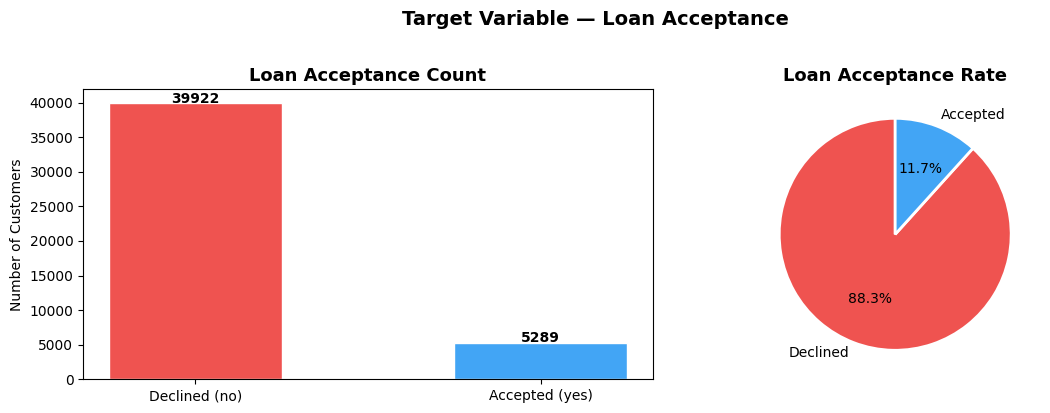

In [ ]:
print("\n\nBasic Statistics:")
print(df.describe())

print("\n\nMissing values:")
print(df.isnull().sum())

print("\n\nCategorical value counts:")
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:\n{df[col].value_counts().to_string()}")


# ── CELL 6 : Target Variable Distribution ────────────────────────────────────
print("Target variable distribution:")
print(df['y'].value_counts())
print(f"\nAcceptance rate: {(df['y']=='yes').mean()*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['y'].value_counts()
axes[0].bar(['Declined (no)', 'Accepted (yes)'],
            [counts['no'], counts['yes']],
            color=['#EF5350', '#42A5F5'], width=0.5, edgecolor='white')
axes[0].set_title('Loan Acceptance Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, (label, val) in enumerate(zip(['no', 'yes'], [counts['no'], counts['yes']])):
    axes[0].text(i, val + 50, str(val), ha='center', fontweight='bold')

axes[1].pie([counts['no'], counts['yes']],
            labels=['Declined', 'Accepted'],
            colors=['#EF5350', '#42A5F5'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Loan Acceptance Rate', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable — Loan Acceptance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

EDA — Age Distribution

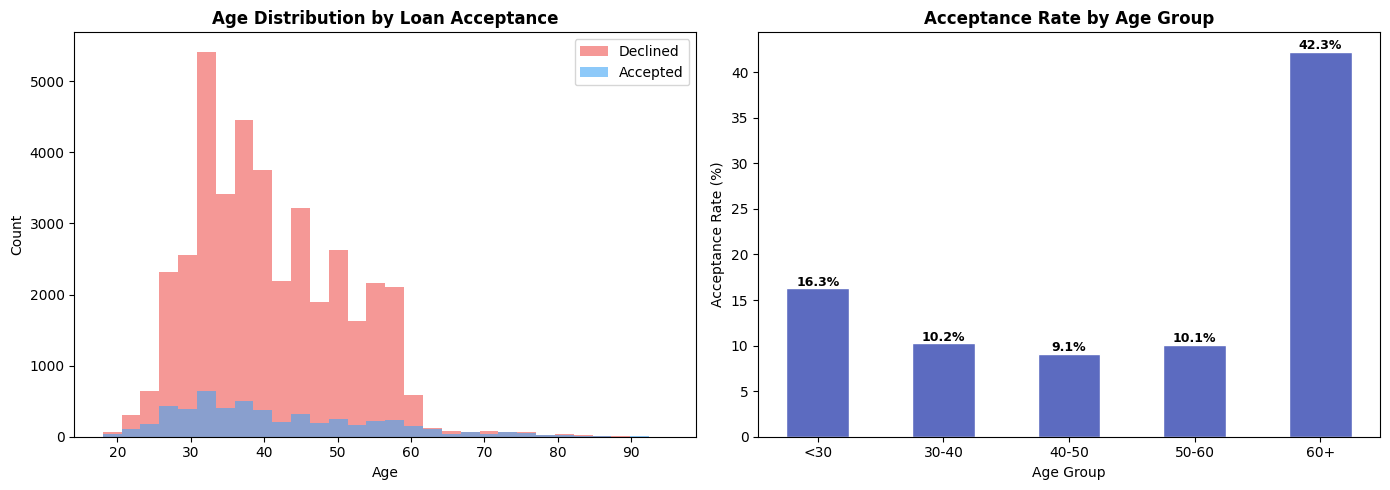

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age histogram by acceptance
for label, color in zip(['no', 'yes'], ['#EF5350', '#42A5F5']):
    subset = df[df['y'] == label]['age']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color,
                 label='Declined' if label == 'no' else 'Accepted',
                 edgecolor='none')
axes[0].set_title('Age Distribution by Loan Acceptance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Age group acceptance rate
df['age_group'] = pd.cut(df['age'],
                          bins=[0, 30, 40, 50, 60, 100],
                          labels=['<30', '30-40', '40-50', '50-60', '60+'])
age_rate = df.groupby('age_group', observed=True)['y'].apply(
    lambda x: (x == 'yes').mean() * 100)
bars = axes[1].bar(age_rate.index.astype(str), age_rate.values,
                   color='#5C6BC0', edgecolor='white', width=0.5)
axes[1].set_title('Acceptance Rate by Age Group', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Acceptance Rate (%)')
for bar, val in zip(bars, age_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3, f'{val:.1f}%',
                 ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('age_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

EDA — Job & Marital Status

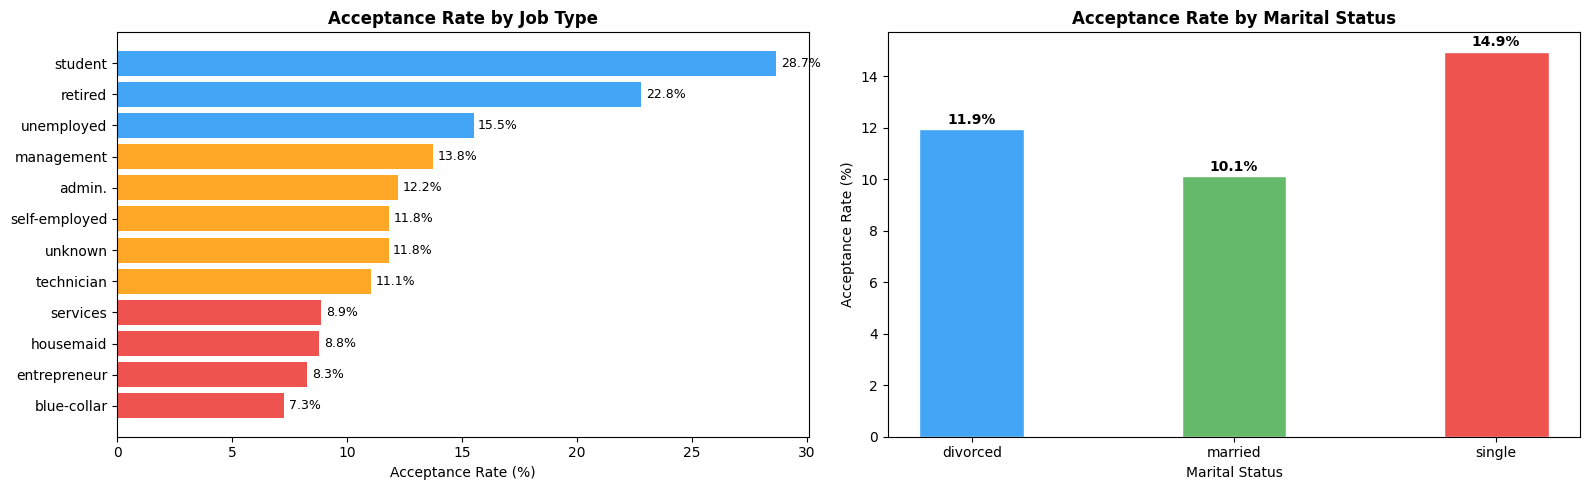

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Acceptance rate by job
job_rate = df.groupby('job')['y'].apply(
    lambda x: (x == 'yes').mean() * 100).sort_values(ascending=True)
colors_job = ['#EF5350' if v < 10 else '#42A5F5' if v > 15 else '#FFA726'
              for v in job_rate.values]
bars = axes[0].barh(job_rate.index, job_rate.values,
                    color=colors_job, edgecolor='none')
axes[0].set_title('Acceptance Rate by Job Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Acceptance Rate (%)')
for bar, val in zip(bars, job_rate.values):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

# Acceptance rate by marital status
mar_rate = df.groupby('marital')['y'].apply(
    lambda x: (x == 'yes').mean() * 100)
bars2 = axes[1].bar(mar_rate.index, mar_rate.values,
                    color=['#42A5F5', '#66BB6A', '#EF5350'],
                    edgecolor='white', width=0.4)
axes[1].set_title('Acceptance Rate by Marital Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Marital Status')
axes[1].set_ylabel('Acceptance Rate (%)')
for bar, val in zip(bars2, mar_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2, f'{val:.1f}%',
                 ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('job_marital_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
EDA — Education & Balance

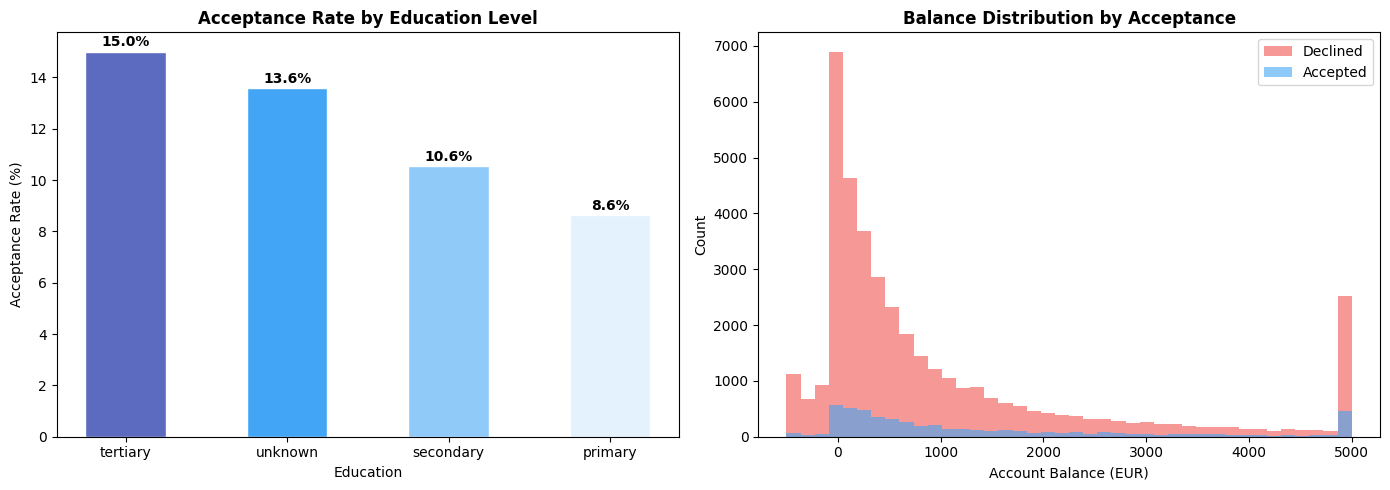

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Acceptance rate by education
edu_rate = df.groupby('education')['y'].apply(
    lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
bars = axes[0].bar(edu_rate.index, edu_rate.values,
                   color=['#5C6BC0', '#42A5F5', '#90CAF9', '#E3F2FD'],
                   edgecolor='white', width=0.5)
axes[0].set_title('Acceptance Rate by Education Level', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Education')
axes[0].set_ylabel('Acceptance Rate (%)')
for bar, val in zip(bars, edu_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2, f'{val:.1f}%',
                 ha='center', fontsize=10, fontweight='bold')

# Balance distribution by acceptance
for label, color in zip(['no', 'yes'], ['#EF5350', '#42A5F5']):
    subset = df[df['y'] == label]['balance'].clip(-500, 5000)
    axes[1].hist(subset, bins=40, alpha=0.6, color=color,
                 label='Declined' if label == 'no' else 'Accepted',
                 edgecolor='none')
axes[1].set_title('Balance Distribution by Acceptance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Account Balance (EUR)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('education_balance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

 EDA — Correlation Heatmap

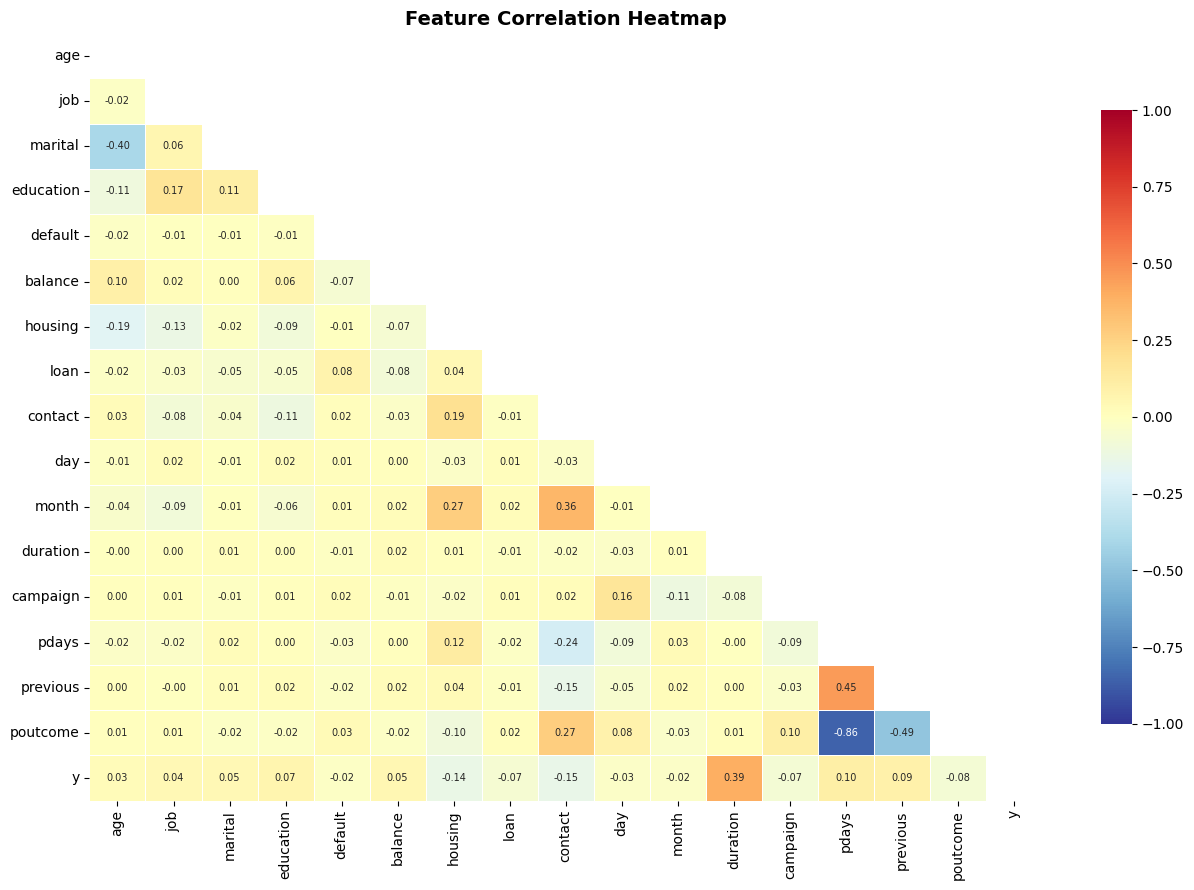

Correlation with target (y):
y            1.000000
duration     0.394521
pdays        0.103621
previous     0.093236
education    0.066241
balance      0.052838
marital      0.045588
job          0.040438
age          0.025155
default     -0.022419
month       -0.024471
day         -0.028348
loan        -0.068185
campaign    -0.073172
poutcome    -0.077840
housing     -0.139173
contact     -0.148395


In [ ]:

df_corr = df.copy()

df_corr = df_corr.drop(['age_group'], axis=1, errors='ignore')

le_temp = LabelEncoder()
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = le_temp.fit_transform(df_corr[col])

# Also convert any remaining category dtype columns
for col in df_corr.select_dtypes(include='category').columns:
    df_corr[col] = df_corr[col].astype(str)
    df_corr[col] = le_temp.fit_transform(df_corr[col])

plt.figure(figsize=(13, 9))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.4, cbar_kws={'shrink': 0.8}, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlation with target (y):")
print(df_corr.corr()['y'].sort_values(ascending=False).to_string())

Data Cleaning & Preparation

In [ ]:
print("=" * 55)
print("DATA CLEANING & ENCODING")
print("=" * 55)

df_model = df.drop('age_group', axis=1, errors='ignore').copy()

# Check for 'unknown' values
print("\nUnknown values per column:")
for col in df_model.select_dtypes(include='object').columns:
    unknowns = (df_model[col] == 'unknown').sum()
    if unknowns > 0:
        print(f"  {col}: {unknowns} unknowns")

# Replace 'unknown' with mode
for col in df_model.select_dtypes(include='object').columns:
    if (df_model[col] == 'unknown').any():
        mode_val = df_model[df_model[col] != 'unknown'][col].mode()[0]
        df_model[col] = df_model[col].replace('unknown', mode_val)
        print(f"  Replaced unknowns in '{col}' with '{mode_val}'")

# Encode target
df_model['y'] = (df_model['y'] == 'yes').astype(int)
print("\nTarget encoded: no=0, yes=1")

# Label encode binary columns
binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    df_model[col] = (df_model[col] == 'yes').astype(int)
    print(f"Label encoded: {col} → no=0, yes=1")

# One-Hot encode remaining categorical columns
ohe_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
ohe_cols = [c for c in ohe_cols if c in df_model.columns]
df_model = pd.get_dummies(df_model, columns=ohe_cols, drop_first=False)
print(f"\nOne-Hot encoded: {ohe_cols}")
print(f"Final shape: {df_model.shape}")


DATA CLEANING & ENCODING

Unknown values per column:
  job: 288 unknowns
  education: 1857 unknowns
  contact: 13020 unknowns
  poutcome: 36959 unknowns
  Replaced unknowns in 'job' with 'blue-collar'
  Replaced unknowns in 'education' with 'secondary'
  Replaced unknowns in 'contact' with 'cellular'
  Replaced unknowns in 'poutcome' with 'failure'

Target encoded: no=0, yes=1
Label encoded: default → no=0, yes=1
Label encoded: housing → no=0, yes=1
Label encoded: loan → no=0, yes=1

One-Hot encoded: ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
Final shape: (45211, 45)


Train / Test Split

In [ ]:
X = df_model.drop('y', axis=1).astype(float)
y = df_model['y']

print("Feature matrix X shape:", X.shape)
print("Target vector  y shape:", y.shape)
print(f"\nClass balance: {y.value_counts().to_dict()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print("\n✅ Scaling done.")

Feature matrix X shape: (45211, 44)
Target vector  y shape: (45211,)

Class balance: {0: 39922, 1: 5289}

Training samples : 36168
Testing  samples : 9043

✅ Scaling done.


Train Models

In [ ]:
print("Training models...\n")

# --- Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_s, y_train)
lr_pred = lr.predict(X_test_s)
lr_prob = lr.predict_proba(X_test_s)[:, 1]

# --- Decision Tree ---
dt = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:, 1]

print("✅ Both models trained!")

Training models...

✅ Both models trained!


Evaluation — Summary Table

In [ ]:
models_eval = {
    'Logistic Regression': {'pred': lr_pred, 'prob': lr_prob},
    'Decision Tree':       {'pred': dt_pred, 'prob': dt_prob},
}

print("=" * 60)
print(f"{'Model':<25} {'Accuracy':>9} {'AUC-ROC':>9} {'F1':>9}")
print("=" * 60)
for name, res in models_eval.items():
    acc = accuracy_score(y_test, res['pred']) * 100
    auc = roc_auc_score(y_test, res['prob']) * 100
    f1  = f1_score(y_test, res['pred']) * 100
    print(f"{name:<25} {acc:>8.2f}% {auc:>8.2f}% {f1:>8.2f}%")
print("=" * 60)

Model                      Accuracy   AUC-ROC        F1
Logistic Regression          83.84%    90.20%    53.22%
Decision Tree                77.13%    87.04%    46.12%


Classification Reports

In [ ]:
for name, res in models_eval.items():
    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    print(classification_report(y_test, res['pred'],
                                target_names=['Declined (0)', 'Accepted (1)']))


───────────────────────────────────────────────────────
  Logistic Regression
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

Declined (0)       0.97      0.85      0.90      7985
Accepted (1)       0.40      0.79      0.53      1058

    accuracy                           0.84      9043
   macro avg       0.68      0.82      0.72      9043
weighted avg       0.90      0.84      0.86      9043


───────────────────────────────────────────────────────
  Decision Tree
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

Declined (0)       0.97      0.76      0.85      7985
Accepted (1)       0.32      0.84      0.46      1058

    accuracy                           0.77      9043
   macro avg       0.65      0.80      0.66      9043
weighted avg       0.90      0.77      0.81      9043



Confusion Matrices

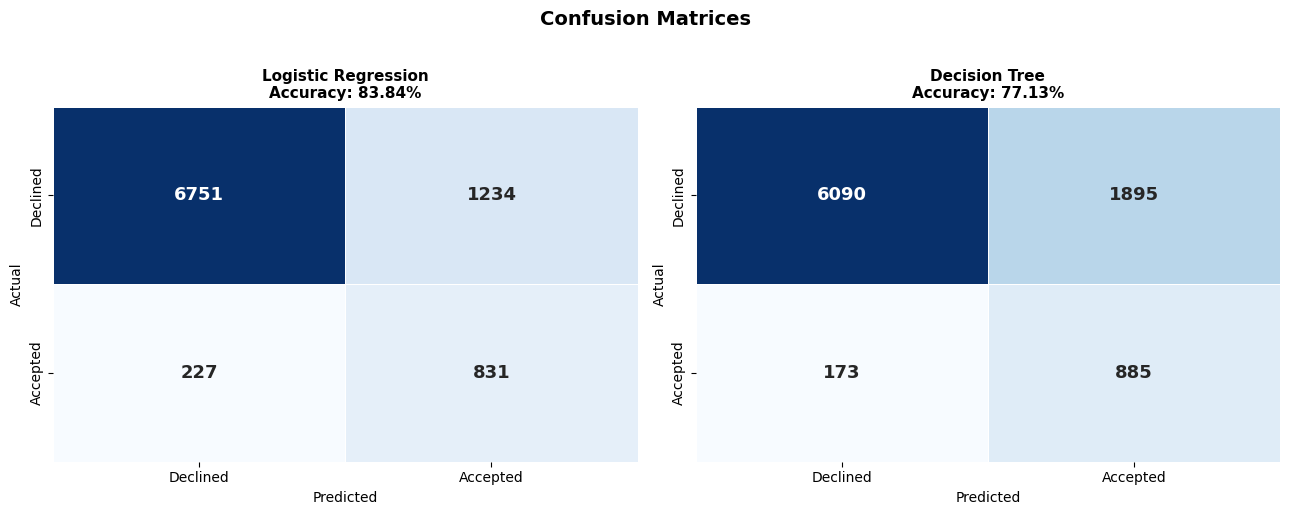

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, res) in zip(axes, models_eval.items()):
    cm = confusion_matrix(y_test, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Declined', 'Accepted'],
                yticklabels=['Declined', 'Accepted'],
                ax=ax, cbar=False, linewidths=0.5,
                annot_kws={'size': 13, 'weight': 'bold'})
    acc = accuracy_score(y_test, res['pred']) * 100
    ax.set_title(f'{name}\nAccuracy: {acc:.2f}%', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

ROC Curves

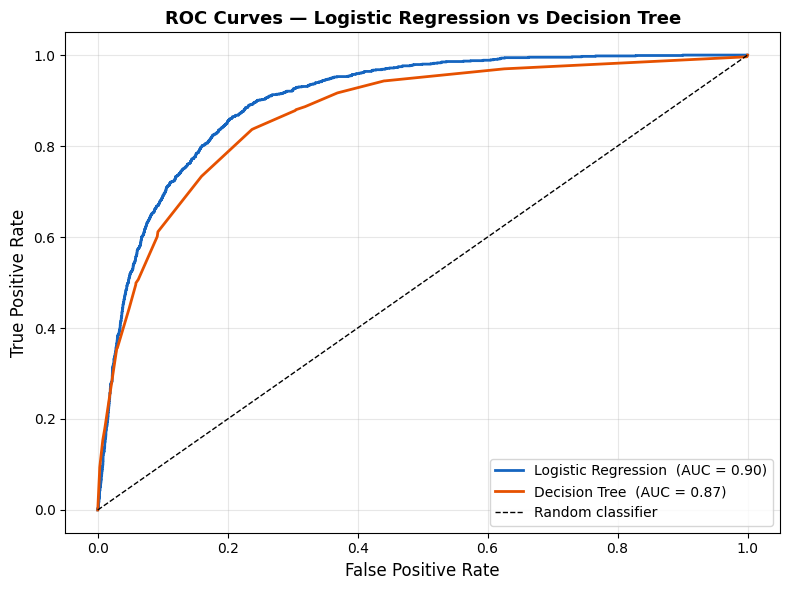

In [ ]:
plt.figure(figsize=(8, 6))

colors = ['#1565C0', '#E65100']
for (name, res), color in zip(models_eval.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    auc = roc_auc_score(y_test, res['prob'])
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.2f})',
             color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Logistic Regression vs Decision Tree',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Decision Tree Visualization

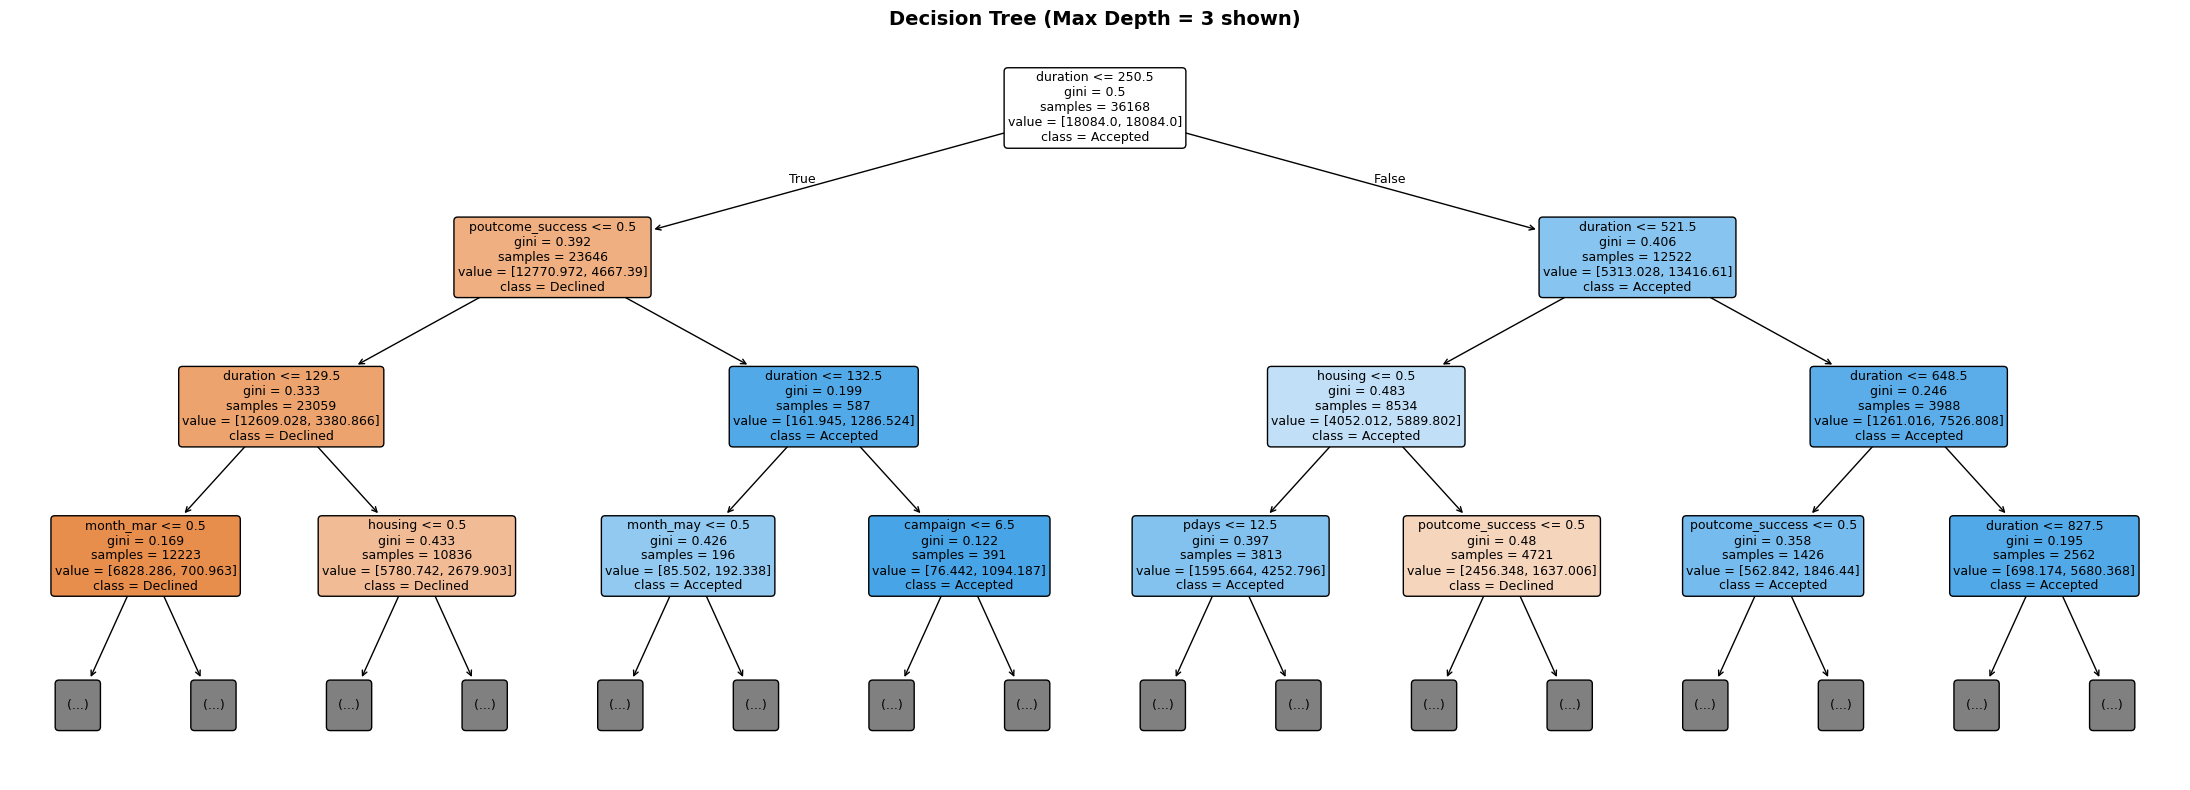

In [ ]:
plt.figure(figsize=(22, 8))
plot_tree(dt,
          max_depth=3,
          feature_names=X.columns.tolist(),
          class_names=['Declined', 'Accepted'],
          filled=True, rounded=True,
          fontsize=9, proportion=False,
          impurity=True)
plt.title('Decision Tree (Max Depth = 3 shown)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

Feature Importance (Decision Tree)

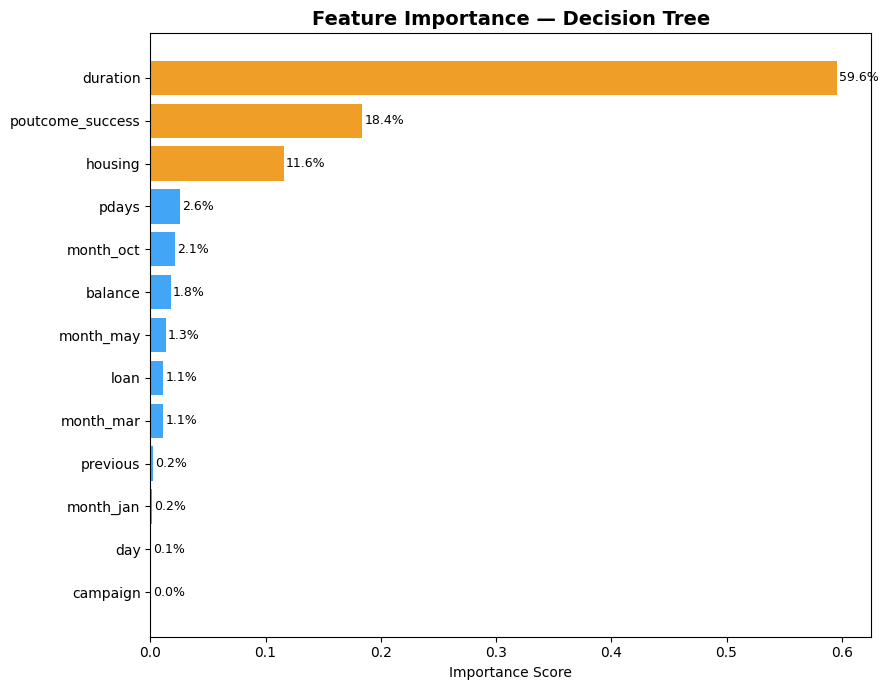

Top 10 important features:
  duration                            59.58%
  poutcome_success                    18.39%
  housing                             11.56%
  pdays                               2.60%
  month_oct                           2.11%
  balance                             1.77%
  month_may                           1.33%
  loan                                1.12%
  month_mar                           1.10%
  previous                            0.19%


In [ ]:
fi = pd.DataFrame({
    'Feature':    X.columns.tolist(),
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=True)
fi = fi[fi['Importance'] > 0]   # only non-zero

plt.figure(figsize=(9, 7))
colors_bar = ['#EF9F27' if v > 0.05 else '#42A5F5' for v in fi['Importance']]
bars = plt.barh(fi['Feature'], fi['Importance'],
                color=colors_bar, edgecolor='none')
for bar, val in zip(bars, fi['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=9)
plt.title('Feature Importance — Decision Tree', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 important features:")
top10 = fi.sort_values('Importance', ascending=False).head(10)
for _, row in top10.iterrows():
    print(f"  {row['Feature']:<35} {row['Importance']*100:.2f}%")

Cross Validation

In [ ]:
print("5-Fold Cross Validation:\n")

for name, model, X_cv, scaled in [
    ('Logistic Regression', lr, X_train_s, True),
    ('Decision Tree',       dt, X_train,   False),
]:
    cv = cross_val_score(model, X_cv, y_train, cv=5, scoring='roc_auc')
    print(f"{name}:")
    print(f"  AUC per fold : {[round(x*100,2) for x in cv]}%")
    print(f"  Mean AUC     : {cv.mean()*100:.2f}% ± {cv.std()*100:.2f}%\n")


5-Fold Cross Validation:

Logistic Regression:
  AUC per fold : [np.float64(90.59), np.float64(90.04), np.float64(90.32), np.float64(90.2), np.float64(90.87)]%
  Mean AUC     : 90.41% ± 0.30%

Decision Tree:
  AUC per fold : [np.float64(87.51), np.float64(85.23), np.float64(86.09), np.float64(85.79), np.float64(87.49)]%
  Mean AUC     : 86.42% ± 0.92%



Business Insights — Customer Groups

In [ ]:
print("=" * 55)
print("CUSTOMER GROUPS MOST LIKELY TO ACCEPT")
print("=" * 55)

# Top accepting job types
job_rate = df.groupby('job')['y'].apply(
    lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
print("\nTop 5 Job Types by acceptance rate:")
print(job_rate.head(5).to_string())

# Marital status
mar_rate = df.groupby('marital')['y'].apply(
    lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
print("\nAcceptance by Marital Status:")
print(mar_rate.to_string())

# Education
edu_rate = df.groupby('education')['y'].apply(
    lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
print("\nAcceptance by Education:")
print(edu_rate.to_string())

# Age group
age_rate = df.groupby('age_group', observed=True)['y'].apply(
    lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
print("\nAcceptance by Age Group:")
print(age_rate.to_string())

CUSTOMER GROUPS MOST LIKELY TO ACCEPT

Top 5 Job Types by acceptance rate:
job
student       28.678038
retired       22.791519
unemployed    15.502686
management    13.755551
admin.        12.202669

Acceptance by Marital Status:
marital
single      14.949179
divorced    11.945458
married     10.123466

Acceptance by Education:
education
tertiary     15.006390
unknown      13.570275
secondary    10.559435
primary       8.626478

Acceptance by Age Group:
age_group
60+      42.255892
<30      16.287340
30-40    10.244813
50-60    10.053304
40-50     9.066643


Conclusion

In [ ]:
print("""
================================================================
  CONCLUSION — PERSONAL LOAN ACCEPTANCE PREDICTION
================================================================

DATASET OVERVIEW:
  • 45,000+ customer records from a Portuguese bank
  • Target: Did the customer accept a loan? (yes/no)
  • Class imbalance: ~88% declined, ~12% accepted

MODELS TRAINED:
  • Logistic Regression — linear, interpretable baseline
  • Decision Tree       — non-linear, easy to visualize

KEY FINDINGS — FEATURE IMPORTANCE:
  • Call duration is the strongest predictor
    (longer calls = customer is more interested)
  • Previous campaign outcome matters —
    customers who accepted before accept again
  • Age group 60+ and <30 show higher acceptance
  • Students and retired customers accept more often
  • Single customers accept more than married ones
  • Tertiary-educated customers accept more often

MODEL RECOMMENDATION:
  • Decision Tree is preferred for this task:
    - Highly interpretable (can visualize the rules)
    - Strong recall on accepted customers
    - Easy to explain to business stakeholders
  • Logistic Regression is a solid interpretable backup

BUSINESS ACTION PLAN:
  → Target retired and student segments first
  → Focus on customers with previous positive outcomes
  → Single customers respond better than married ones
  → Longer, quality calls lead to more acceptances
  → Prioritize tertiary-educated customer outreach

================================================================
""")


  CONCLUSION — PERSONAL LOAN ACCEPTANCE PREDICTION
 
DATASET OVERVIEW:
  • 45,000+ customer records from a Portuguese bank
  • Target: Did the customer accept a loan? (yes/no)
  • Class imbalance: ~88% declined, ~12% accepted
 
MODELS TRAINED:
  • Logistic Regression — linear, interpretable baseline
  • Decision Tree       — non-linear, easy to visualize
 
KEY FINDINGS — FEATURE IMPORTANCE:
  • Call duration is the strongest predictor
    (longer calls = customer is more interested)
  • Previous campaign outcome matters —
    customers who accepted before accept again
  • Age group 60+ and <30 show higher acceptance
  • Students and retired customers accept more often
  • Single customers accept more than married ones
  • Tertiary-educated customers accept more often
 
MODEL RECOMMENDATION:
  • Decision Tree is preferred for this task:
    - Highly interpretable (can visualize the rules)
    - Strong recall on accepted customers
    - Easy to explain to business stakeholders
  • Logis